# Choosing a segmentation technique: 3D true vs 3D stitched

Cellpose can segment a stack two ways: natively in 3D (`do_3D`), or per z-plane
with the 2D masks stitched together afterwards (`stitch_threshold`). They fail
differently, and both failures show up in **z**:

* **how far each mask reaches through z** — a pile of masks that live on a single
  plane is stitching that never joined them up (yield thrown away by a `min_z`
  filter); a long tail of masks reaching through the whole stack is over-merging
  (two nuclei stacked in z read as one).
* **how much a mask changes size between adjacent layers** — planes are a few
  hundred nanometres apart, so a nucleus's cross-section should grow to a
  mid-plane and shrink away from it smoothly. A mask whose area jumps between
  adjacent layers is usually the segmenter changing its mind, and per-plane
  stitching has a per-plane decision to be inconsistent about where a native
  `do_3D` run does not.

This notebook runs both measurements — first as a walk-through on one run, then
on both techniques on the same field, side by side.

## What is in the two files

`segmentation_z_helpers.py` is `segmentation_z_claude.py` moved into a module:
same function bodies, same defaults, same printed wording. The changes were:

1. `LAYER_SPAN_CUTOFF`, `AREA_CHANGE_CUTOFF`, `CHANGE_REFERENCE` and
   `OBJECT_STATISTIC` were module globals read inside `build_span_layers`,
   `give_output_summary`, `give_change_summary` and `launch_viewer`; they are now
   keyword arguments with the same defaults. The notebook calls those functions
   once per technique, and a global would silently apply one technique's settings
   to the other.
2. `plot_area_change`'s `path` defaults to `None` rather than
   `Path("z_area_change.png")`. In a notebook the figure *is* the output, so the
   default now renders inline; pass `path=...` to write the PNG as before.
3. `import napari` moved inside `launch_viewer`. napari pulls in Qt and is the
   one dependency a headless kernel usually lacks, so importing it at module
   level would stop the whole analysis from running there.
4. `main()` became `analyse_masks()` — the same call sequence with the loading,
   printing and viewer launch lifted out. Those steps are their own cells below,
   and the comparison loop needs to re-run the analysis without re-narrating it.
5. `plot_area_change`'s left panel and its `log_hist_range` helper come from
   `segmentation_z_claude_log.py` instead of `segmentation_z_claude.py`, so the
   |Δ area| / area distribution is log-binned on a log x axis. That is the only
   difference between the two scripts, and it is a display transform only — the
   mean and the `cutoff x mean` threshold are still plain arithmetic means, so
   the flagged objects and the napari layer are identical either way.

Everything after that (the palette, the two comparison figures) is new, and
exists only because the script analysed one run and a choice between techniques
needs two.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import segmentation_z_helpers as h

h.apply_theme()   # same figure style as zspan/plotting.py
pd.set_option("display.width", 140)

### Config

In [2]:
DATA_ROOT = Path("data")

FAMILY = "cpdino"
PREPROCESSING = "decon"
MODEL = "VePo"
REGION = "region_UWA-7648"
FOV = "fov_07"

DAPI_DIR = DATA_ROOT / "patches" / MODEL / REGION / FOV
DAPI_GLOB = str(DAPI_DIR / "DAPI_decon_z*.tif")   # one file per z index

METHODS = {
    "3D true":     DATA_ROOT / "segmentations_3d_true"     / FAMILY / PREPROCESSING / MODEL / REGION / FOV / "masks.tif",
    "3D stitched": DATA_ROOT / "segmentations_3d_stitched" / FAMILY / PREPROCESSING / MODEL / REGION / FOV / "masks.tif",
}
PRIMARY = "3D true"         # the run the walk-through below uses

LAYER_SPAN_CUTOFF = 1
AREA_CHANGE_CUTOFF = 3.5
CHANGE_REFERENCE = "layer"  # "layer" = mean of that z-transition, "global" = mean of all transitions
OBJECT_STATISTIC = "max"    # collapse each object's transitions with "max" or "mean"

HIST_DECADES = 4            # widest the log histogram may get, in decades below the largest change

for name, path in METHODS.items():
    print(f"{'OK ' if path.exists() else 'MISSING'}  {name:<12} {path}")
print(f"{'OK ' if DAPI_DIR.exists() else 'MISSING'}  {'DAPI':<12} {DAPI_GLOB}")

OK   3D true      data/segmentations_3d_true/cpdino/decon/VePo/region_UWA-7648/fov_07/masks.tif
OK   3D stitched  data/segmentations_3d_stitched/cpdino/decon/VePo/region_UWA-7648/fov_07/masks.tif
OK   DAPI         data/patches/VePo/region_UWA-7648/fov_07/DAPI_decon_z*.tif


## 1. Load in data

In [3]:
dapi, masks, files = h.load_data(DAPI_GLOB, METHODS[PRIMARY])

print(f"{len(files)} DAPI planes, dtype {dapi.dtype}")
print(f"masks dtype {masks.dtype}, labels 1..{int(masks.max())}")

Volume shape: (7, 4000, 4000)  |  2541 labeled objects
7 DAPI planes, dtype uint16
masks dtype uint32, labels 1..2541


## 2. How far does each mask reach through z?

`check_z_span` takes the z bounding box of every label — `find_objects` gives the
slice per label, and its `start`/`stop` are the first and last plane the mask
appears on. `z_span` is the inclusive depth in planes: 1 means the mask lives on
a single plane.

In [4]:
spans = h.check_z_span(masks, layer_span_cutoff=LAYER_SPAN_CUTOFF)
h.give_output_summary(spans, layer_span_cutoff=LAYER_SPAN_CUTOFF)
spans.head(10)


=== Z-SPAN SUMMARY ===
  n_objects: 2541
  n_single_slice (z_span==1): 0
  n_two_slice (z_span==2): 26
  n_spans_multiple_layers (z_span>1): 2541


,label,z_start,z_end,z_span,spans_multiple_layers
0,1,0,6,7,True
1,2,0,6,7,True
2,3,0,3,4,True
3,4,0,3,4,True
4,5,0,6,7,True
5,6,0,6,7,True
6,7,0,6,7,True
7,8,0,3,4,True
8,9,0,6,7,True
9,10,0,6,7,True


The summary prints three numbers; the full distribution is what the technique
comparison turns on, so it is worth seeing whole. A spike at `z_span == 1` is
masks a `min_z = 3` filter would discard outright.

In [5]:
(spans["z_span"]
 .value_counts()
 .sort_index()
 .rename_axis("z_span")
 .to_frame("n_masks")
 .assign(pct=lambda t: (100 * t["n_masks"] / len(spans)).round(1)))

,n_masks,pct
z_span,,
2,26,1.0
3,160,6.3
4,333,13.1
5,341,13.4
6,374,14.7
7,1307,51.4


## 3. How much does each mask change size between layers?

Three steps in one cell:

1. `measure_slice_areas` — pixel count of every label on every plane, as an
   `(n_z, n_labels + 1)` array (column 0 is background). One `bincount` per
   plane, so it is one pass over the volume.
2. `check_area_change` — differences those along z. **One row per
   (object, z-transition)**, and only where the object is present in *both*
   planes, so a mask appearing or disappearing does not register as a 100%
   change.
3. `summarise_layer_change` — collapses to one row per z-transition.

In [6]:
areas = h.measure_slice_areas(masks)
print(f"areas: {areas.shape}  (n_z x n_labels+1)")

changes = h.check_area_change(masks)
print(f"changes: {len(changes)} object-transitions")

layer_stats = h.summarise_layer_change(changes)
layer_stats

areas: (7, 2542)  (n_z x n_labels+1)
changes: 12413 object-transitions


,z_from,z_to,mean_change,std_change,n_objects
0,0,1,1.378357,5.482012,1707
1,1,2,1.545017,8.415317,1980
2,2,3,1.381408,6.084529,2157
3,3,4,1.339600,6.330891,2226
4,4,5,0.605691,3.192645,2220
5,5,6,0.219689,0.255494,2123


### Flagging the objects that jump relative to set of masks

In [7]:
per_object = h.flag_area_outliers(
    changes, layer_stats,
    cutoff=AREA_CHANGE_CUTOFF,
    reference=CHANGE_REFERENCE,
    statistic=OBJECT_STATISTIC,
)

labels_primary = spans.merge(per_object, on="label", how="left")
labels_primary["large_area_change"] = labels_primary["large_area_change"].fillna(False).astype(bool)

h.give_change_summary(
    labels_primary, changes, layer_stats,
    cutoff=AREA_CHANGE_CUTOFF,
    reference=CHANGE_REFERENCE,
    statistic=OBJECT_STATISTIC,
)
labels_primary.sort_values("change_ratio", ascending=False).head(10)


=== AREA-CHANGE SUMMARY ===
  n_transitions measured: 12413
  mean |Δarea|/area: 1.062
  median |Δarea|/area: 0.205
  reference: layer  |  object statistic: max
  n_large_area_change (> 3.5x mean): 505

  per-layer mean |Δarea|/area:
    z 0->1: 1.378 ± 5.482  (n=1707)
    z 1->2: 1.545 ± 8.415  (n=1980)
    z 2->3: 1.381 ± 6.085  (n=2157)
    z 3->4: 1.340 ± 6.331  (n=2226)
    z 4->5: 0.606 ± 3.193  (n=2220)
    z 5->6: 0.220 ± 0.255  (n=2123)


,label,z_start,z_end,z_span,spans_multiple_layers,n_transitions,mean_abs_change,max_abs_change,change_ratio,large_area_change
2448,2449,4,6,3,True,2,39.843750,79.00,130.429570,True
2045,2046,2,6,5,True,4,42.608173,170.00,123.062828,True
1757,1758,1,6,6,True,5,35.624992,177.00,114.561866,True
2481,2482,4,6,3,True,2,32.315385,64.00,105.664461,True
1978,1979,1,6,6,True,5,26.464960,131.00,84.788726,True
1828,1829,1,6,6,True,5,25.723295,127.75,82.685189,True
2506,2507,4,6,3,True,2,25.186275,50.00,82.550360,True
2414,2415,4,6,3,True,2,25.235294,50.00,82.550360,True
1836,1837,1,6,6,True,5,25.338380,126.00,81.552515,True
1231,1232,0,6,7,True,6,18.708669,111.00,80.530656,True


## 4. The script's figure

Left: the distribution of per-transition area change, log-binned on a **log x
axis**, with the mean and the flag threshold marked. Right: the mean per
z-transition with its IQR band — i.e. the flag reference, layer by layer.

The log axis is a display transform and nothing more: the mean and the
`cutoff x mean` threshold are still plain arithmetic means of `abs_frac_change`,
so the objects flagged as `large_area_change` — and the napari layer built from
them — are exactly the ones the linear version flags.

`log_hist_range` picks the span. `top` is the largest observed change, since on
a log axis the right tail costs almost no width and there is no reason to
truncate it; `lo` is the decade holding the smallest *positive* change, floored
at `HIST_DECADES` below `top` so a single near-zero transition cannot stretch the
panel over ten empty decades. Log bins cannot hold zero, so both tails are folded
into the edge bins and counted in the annotation rather than dropped — the
"no area change" note is the exactly-stable transitions, which on real data is
usually a substantial share.

`hist_xmin` and `hist_xmax` override the span, `layer_ymax` clips the right
panel with the amount annotated, and `spread` switches its band between `"iqr"`,
`"sem"`, `"sd"` and `None`.

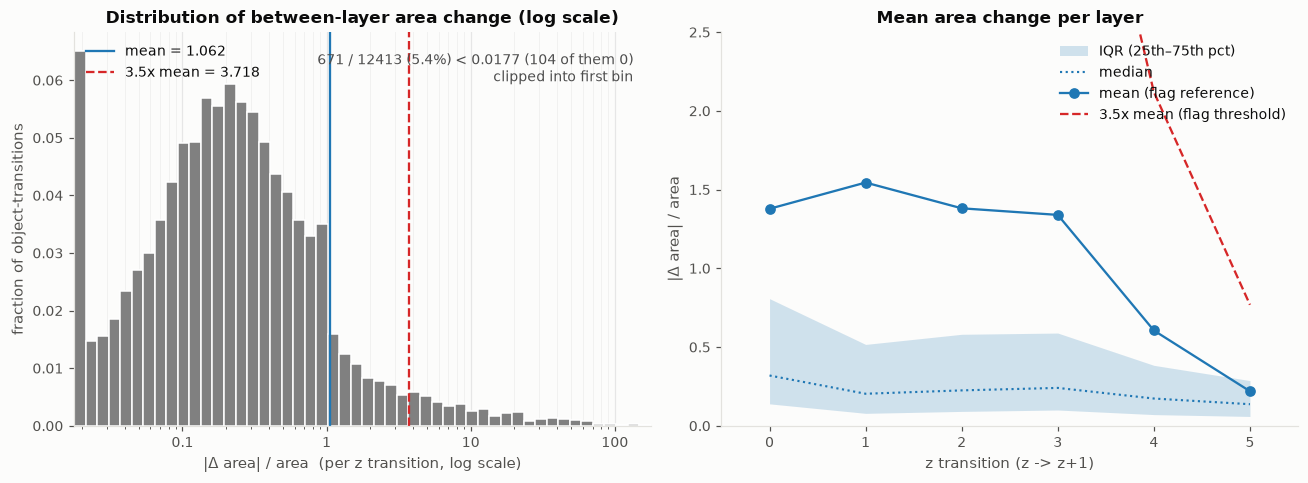

In [8]:
fig = h.plot_area_change(
    changes, layer_stats,
    cutoff=AREA_CHANGE_CUTOFF,
    path=None,          # None -> inline; pass a Path to write the PNG as the script did
    spread="iqr",
    hist_decades=HIST_DECADES,
)

## 5. Both techniques, side by side

Everything above, run once per technique. `analyse_masks` is the script's
`main()` analysis block — `check_z_span`, `check_area_change`,
`summarise_layer_change`, `flag_area_outliers`, merge — so the numbers here are
the same ones the walk-through produced, including for `PRIMARY`.

The same DAPI stack is re-read for each technique. That is the cost of keeping
`load_data` as it was, and it buys the assertion that each mask volume actually
lines up with the image it was segmented from.

In [9]:
runs = {}

for name, masks_path in METHODS.items():
    dapi, masks_i, _ = h.load_data(DAPI_GLOB, masks_path)

    labels_i, changes_i, layer_stats_i = h.analyse_masks(
        masks_i,
        layer_span_cutoff=LAYER_SPAN_CUTOFF,
        cutoff=AREA_CHANGE_CUTOFF,
        reference=CHANGE_REFERENCE,
        statistic=OBJECT_STATISTIC,
    )

    runs[name] = {"masks": masks_i, "labels": labels_i,
                  "changes": changes_i, "layer_stats": layer_stats_i}

labels = pd.concat([h.tag(r["labels"], n) for n, r in runs.items()], ignore_index=True)
changes_all = pd.concat([h.tag(r["changes"], n) for n, r in runs.items()], ignore_index=True)

Volume shape: (7, 4000, 4000)  |  2541 labeled objects
Volume shape: (7, 4000, 4000)  |  2931 labeled objects


### Where the masks sit in z

Normalised within each technique, so runs with different mask counts compare
directly. The bar at 1 is the yield a `min_z` filter discards; the `6+` bar is
masks reaching most of the way through the stack.

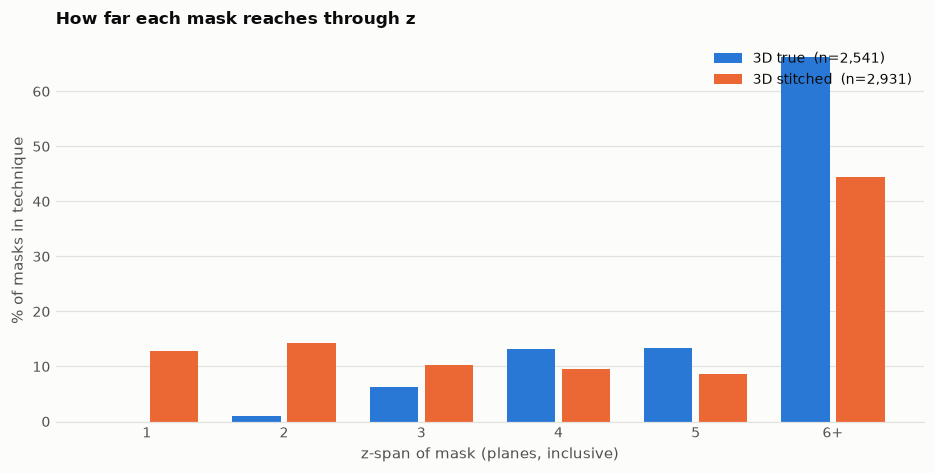

In [10]:
fig = h.compare_span_distribution(labels, max_span=6)

### How steady the masks are, layer by layer

The right panel of section 4's figure, with both techniques on one axes. The flag
threshold is dropped: two means and two thresholds is four lines to read where
two carry the comparison.

A technique that sits higher **everywhere** is less stable overall. A technique
that tracks the other but spikes at particular transitions is worth chasing to
those planes — that is usually one bad plane in the acquisition rather than the
segmenter, and it will show up in both techniques if so. `ymax` is the script's
`layer_ymax`, kept so the axes match section 4; pass `ymax=None` to autoscale,
and any mean above the limit is annotated rather than silently cropped.

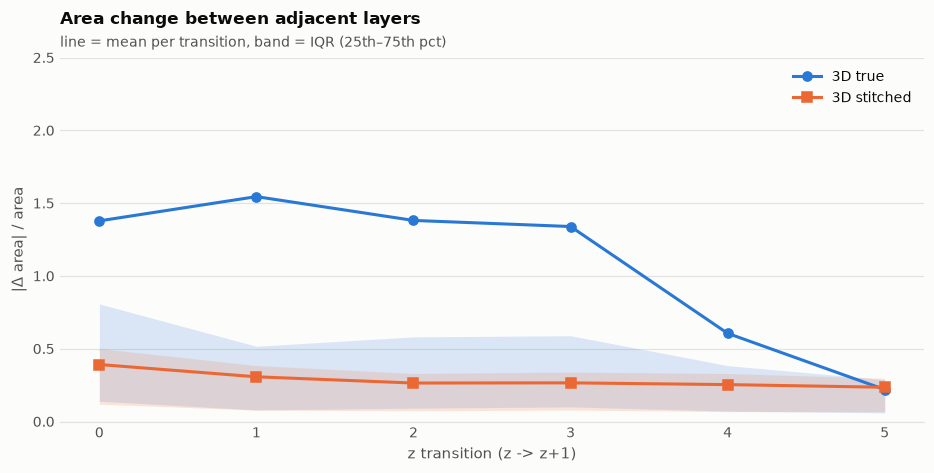

In [11]:
fig = h.compare_layer_change(changes_all, ymax=2.5)

### And each technique's own two-panel figure

Same function as section 4, once per technique. `log_hist_range` autoscales per
run, so `hist_xmin`/`hist_xmax` are pinned to the range covering both — a log
axis that moves under you is not a comparison.


########## 3D true ##########


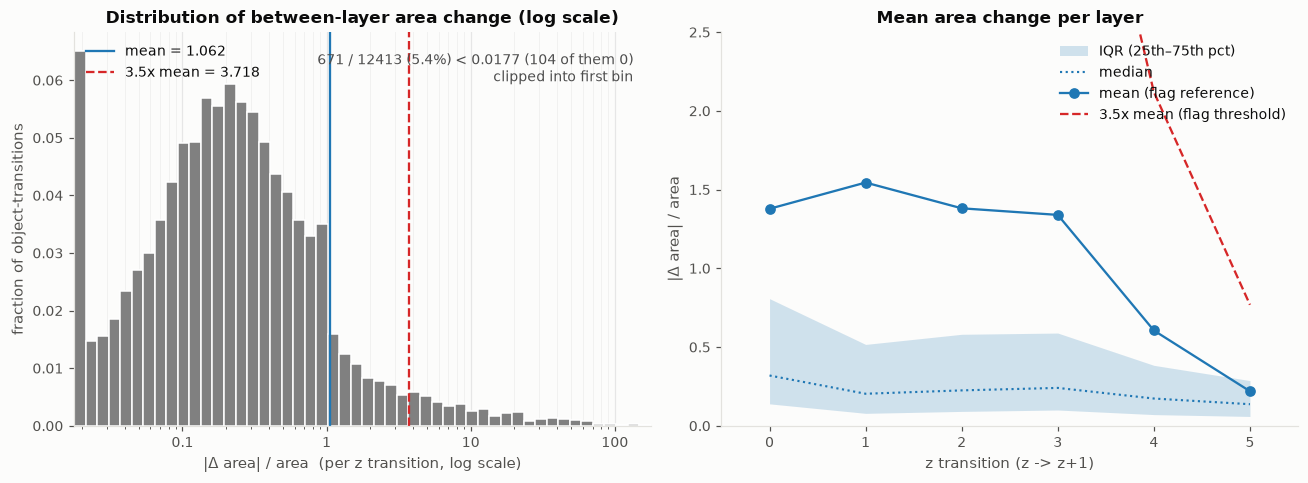


########## 3D stitched ##########


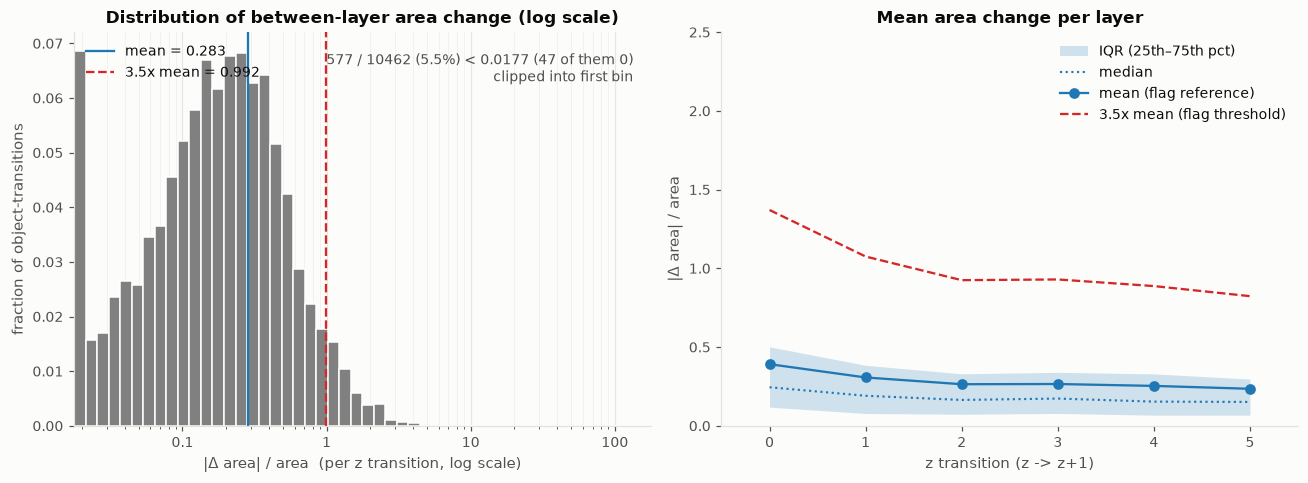

In [12]:
lo, top = h.log_hist_range(changes_all["abs_frac_change"].to_numpy(),
                           hist_decades=HIST_DECADES)

for name, run in runs.items():
    print(f"\n########## {name} ##########")
    h.plot_area_change(run["changes"], run["layer_stats"],
                       cutoff=AREA_CHANGE_CUTOFF, path=None, spread="iqr",
                       hist_xmin=lo, hist_xmax=top)

## 6. Looking at the masks in napari

`build_span_layers` and `build_change_layer` are label-volume filters: each
returns a copy of the mask volume with everything but the selected labels zeroed,
so napari can toggle them as separate label layers over the DAPI. One viewer per
technique, over the same DAPI, so the same nucleus can be found under each.

The viewer blocks the kernel until the window is closed, so it is off by default
— set `LAUNCH_NAPARI = True` in the config cell to use it.

In [ ]:
for name, run in runs.items():
    single_i, two_i = h.build_span_layers(run["masks"], run["labels"],
                                          layer_span_cutoff=LAYER_SPAN_CUTOFF)
    change_i = h.build_change_layer(run["masks"], run["labels"])
    run.update(single=single_i, two=two_i, flagged=change_i)

    print(f"{name}: "
          f"{int((np.unique(single_i) > 0).sum())} x {LAYER_SPAN_CUTOFF}-slice, "
          f"{int((np.unique(two_i) > 0).sum())} x {LAYER_SPAN_CUTOFF + 1}-slice, "
          f"{int((np.unique(change_i) > 0).sum())} flagged >{AREA_CHANGE_CUTOFF}x mean change")

In [ ]:
for name, run in runs.items():
    h.launch_viewer(dapi, run["masks"], run["single"], run["two"], run["flagged"],
                    layer_span_cutoff=LAYER_SPAN_CUTOFF,
                    cutoff=AREA_CHANGE_CUTOFF,
                    title=name)

### Region UCI 2424

In [16]:
# --- 7a. load every FOV in a region, under both techniques -------------------
TECHNIQUE_ROOTS = {
    "3D true":     DATA_ROOT / "segmentations_3d_true"     / FAMILY / PREPROCESSING / MODEL,
    "3D stitched": DATA_ROOT / "segmentations_3d_stitched" / FAMILY / PREPROCESSING / MODEL,
}

# any region present under both techniques; REGION is the one sections 1-6 used
SCAN_REGION = "region_UCI-2424"

print("available:", ", ".join(h.available_regions(TECHNIQUE_ROOTS)))

found = h.find_region_fovs(TECHNIQUE_ROOTS, SCAN_REGION)
print(f"\n{found['fov'].nunique()} paired FOV(s) in {SCAN_REGION}\n")

region_labels, region_changes = h.scan_region(
    found,
    layer_span_cutoff=LAYER_SPAN_CUTOFF,
    cutoff=AREA_CHANGE_CUTOFF,
    reference=CHANGE_REFERENCE,
    statistic=OBJECT_STATISTIC,
)

region_metrics = h.fov_metrics(region_labels, region_changes,
                               layer_span_cutoff=LAYER_SPAN_CUTOFF)

available: region_UCI-2424, region_UCI-4723, region_UCI-5224, region_UWA-7648

3 paired FOV(s) in region_UCI-2424

  fov_01     3D true         195 masks     973 transitions
  fov_01     3D stitched     232 masks    1041 transitions
  fov_07     3D true        1822 masks    9063 transitions
  fov_07     3D stitched    2199 masks    8108 transitions
  fov_09     3D true        1536 masks    7202 transitions
  fov_09     3D stitched    2274 masks    7327 transitions


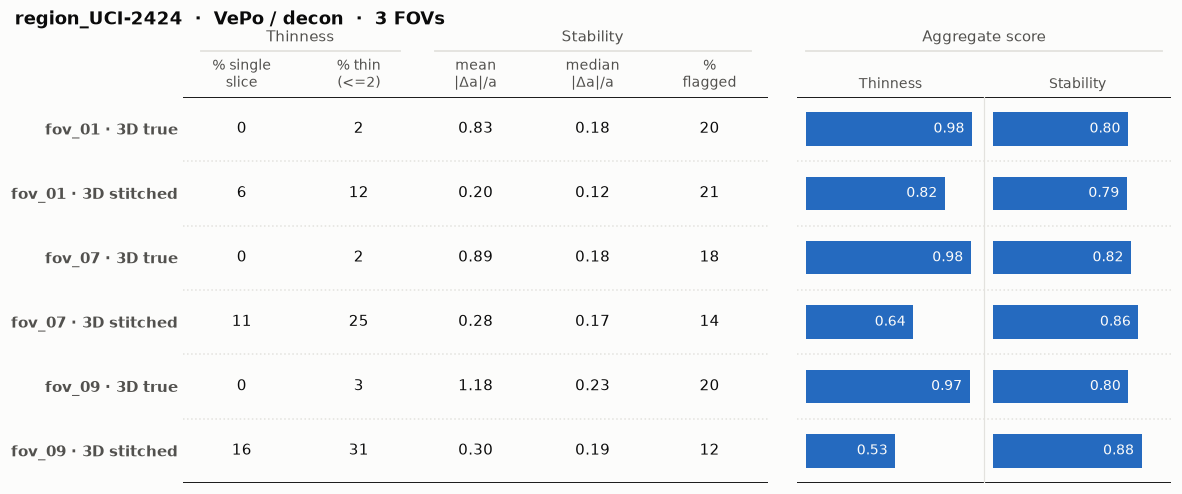

In [17]:
# --- 7b. scorecard ------------------------------------------------------------
fig = h.plot_fov_table(
    region_metrics,
    title=f"{SCAN_REGION}  ·  {MODEL} / {PREPROCESSING}  ·  {found['fov'].nunique()} FOVs",
)

### Region UCI-4723

In [18]:
# --- 7a. load every FOV in a region, under both techniques -------------------
TECHNIQUE_ROOTS = {
    "3D true":     DATA_ROOT / "segmentations_3d_true"     / FAMILY / PREPROCESSING / MODEL,
    "3D stitched": DATA_ROOT / "segmentations_3d_stitched" / FAMILY / PREPROCESSING / MODEL,
}

# any region present under both techniques; REGION is the one sections 1-6 used
SCAN_REGION = "region_UCI-4723"

print("available:", ", ".join(h.available_regions(TECHNIQUE_ROOTS)))

found = h.find_region_fovs(TECHNIQUE_ROOTS, SCAN_REGION)
print(f"\n{found['fov'].nunique()} paired FOV(s) in {SCAN_REGION}\n")

region_labels, region_changes = h.scan_region(
    found,
    layer_span_cutoff=LAYER_SPAN_CUTOFF,
    cutoff=AREA_CHANGE_CUTOFF,
    reference=CHANGE_REFERENCE,
    statistic=OBJECT_STATISTIC,
)

region_metrics = h.fov_metrics(region_labels, region_changes,
                               layer_span_cutoff=LAYER_SPAN_CUTOFF)

available: region_UCI-2424, region_UCI-4723, region_UCI-5224, region_UWA-7648

3 paired FOV(s) in region_UCI-4723

  fov_01     3D true          65 masks     303 transitions
  fov_01     3D stitched      82 masks     338 transitions
  fov_04     3D true         839 masks    4039 transitions
  fov_04     3D stitched     971 masks    3776 transitions
  fov_07     3D true        2178 masks   10261 transitions
  fov_07     3D stitched    2578 masks    9258 transitions


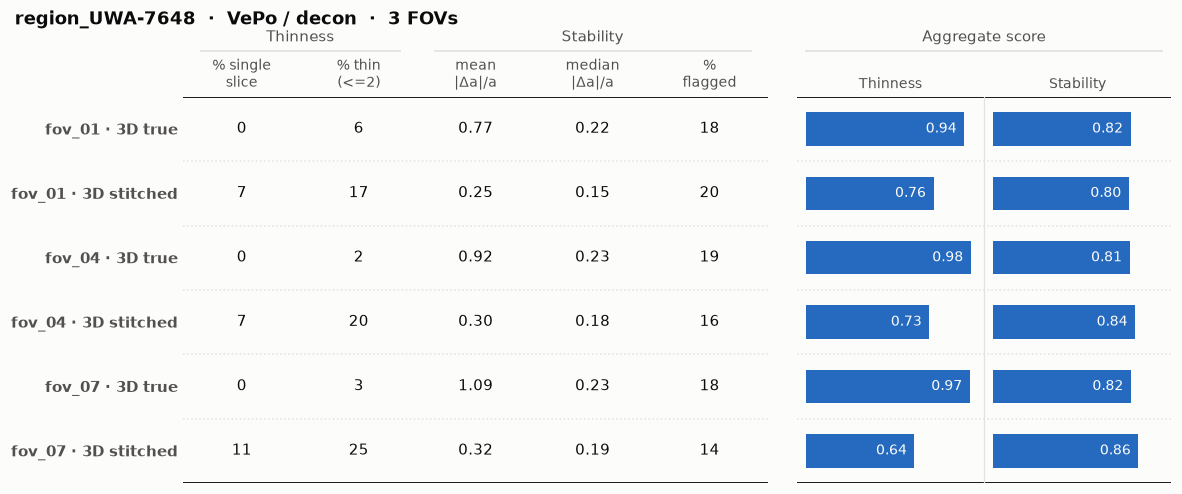

In [19]:
# --- 7b. scorecard ------------------------------------------------------------
fig = h.plot_fov_table(
    region_metrics,
    title=f"{REGION}  ·  {MODEL} / {PREPROCESSING}  ·  {found['fov'].nunique()} FOVs",
)

display, aggregate = h.score_fovs(region_metrics)

### Region UCI-5224

In [20]:
# --- 7a. load every FOV in a region, under both techniques -------------------
TECHNIQUE_ROOTS = {
    "3D true":     DATA_ROOT / "segmentations_3d_true"     / FAMILY / PREPROCESSING / MODEL,
    "3D stitched": DATA_ROOT / "segmentations_3d_stitched" / FAMILY / PREPROCESSING / MODEL,
}

# any region present under both techniques; REGION is the one sections 1-6 used
SCAN_REGION = "region_UCI-5224"

print("available:", ", ".join(h.available_regions(TECHNIQUE_ROOTS)))

found = h.find_region_fovs(TECHNIQUE_ROOTS, SCAN_REGION)
print(f"\n{found['fov'].nunique()} paired FOV(s) in {SCAN_REGION}\n")

region_labels, region_changes = h.scan_region(
    found,
    layer_span_cutoff=LAYER_SPAN_CUTOFF,
    cutoff=AREA_CHANGE_CUTOFF,
    reference=CHANGE_REFERENCE,
    statistic=OBJECT_STATISTIC,
)

region_metrics = h.fov_metrics(region_labels, region_changes,
                               layer_span_cutoff=LAYER_SPAN_CUTOFF)

available: region_UCI-2424, region_UCI-4723, region_UCI-5224, region_UWA-7648

3 paired FOV(s) in region_UCI-5224

  fov_04     3D true        1414 masks    6909 transitions
  fov_04     3D stitched    1592 masks    6214 transitions
  fov_06     3D true        1069 masks    5213 transitions
  fov_06     3D stitched    1301 masks    4805 transitions
  fov_07     3D true        2253 masks   11269 transitions
  fov_07     3D stitched    2603 masks   10001 transitions


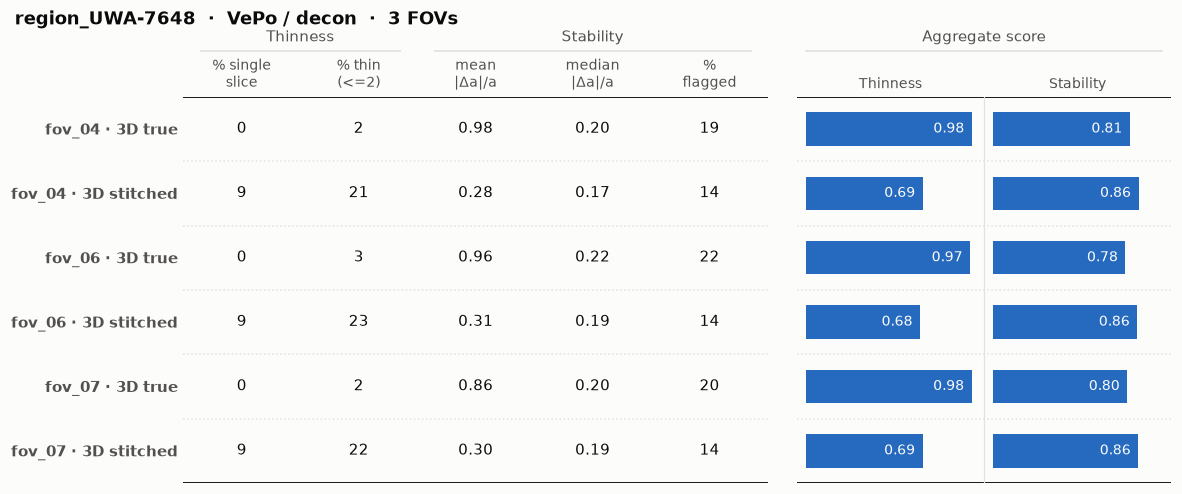

In [21]:
# --- 7b. scorecard ------------------------------------------------------------
fig = h.plot_fov_table(
    region_metrics,
    title=f"{REGION}  ·  {MODEL} / {PREPROCESSING}  ·  {found['fov'].nunique()} FOVs",
)

display, aggregate = h.score_fovs(region_metrics)

### Region UWA-7648

In [22]:
# --- 7a. load every FOV in a region, under both techniques -------------------
TECHNIQUE_ROOTS = {
    "3D true":     DATA_ROOT / "segmentations_3d_true"     / FAMILY / PREPROCESSING / MODEL,
    "3D stitched": DATA_ROOT / "segmentations_3d_stitched" / FAMILY / PREPROCESSING / MODEL,
}

# any region present under both techniques; REGION is the one sections 1-6 used
SCAN_REGION = "region_UWA-7648"

print("available:", ", ".join(h.available_regions(TECHNIQUE_ROOTS)))

found = h.find_region_fovs(TECHNIQUE_ROOTS, SCAN_REGION)
print(f"\n{found['fov'].nunique()} paired FOV(s) in {SCAN_REGION}\n")

region_labels, region_changes = h.scan_region(
    found,
    layer_span_cutoff=LAYER_SPAN_CUTOFF,
    cutoff=AREA_CHANGE_CUTOFF,
    reference=CHANGE_REFERENCE,
    statistic=OBJECT_STATISTIC,
)

region_metrics = h.fov_metrics(region_labels, region_changes,
                               layer_span_cutoff=LAYER_SPAN_CUTOFF)

available: region_UCI-2424, region_UCI-4723, region_UCI-5224, region_UWA-7648

3 paired FOV(s) in region_UWA-7648

  fov_01     3D true         103 masks     476 transitions
  fov_01     3D stitched     139 masks     525 transitions
  fov_07     3D true        2541 masks   12413 transitions
  fov_07     3D stitched    2931 masks   10462 transitions
  fov_09     3D true        1447 masks    7067 transitions
  fov_09     3D stitched    1797 masks    6270 transitions


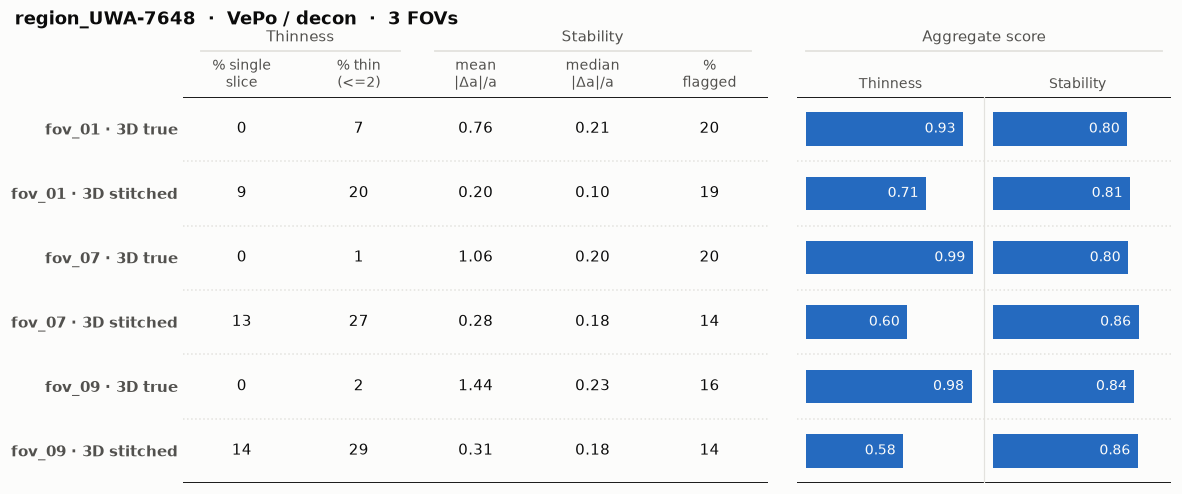

In [23]:
# --- 7b. scorecard ------------------------------------------------------------
fig = h.plot_fov_table(
    region_metrics,
    title=f"{REGION}  ·  {MODEL} / {PREPROCESSING}  ·  {found['fov'].nunique()} FOVs",
)

display, aggregate = h.score_fovs(region_metrics)